# 전체 파이프라인: 반응 스킴 → 자동 분석 → 조성비

### 예시 시나리오

| Role | 화합물 | 설명 |
|------|--------|------|
| **Starting Material 1** | 4-Am-DNT | 주 원료 |
| **Starting Material 2** | 2,4-DNT | 보조 원료 |
| **Product** | TNT | 목표 생성물 |
| **Byproduct** | 2,6-DNT, HMX, Tetryl | 부반응 생성물 |

> **참고**: 실제 데이터는 EPA 8330 표준 혼합물이며, 위 반응은 워크플로우 시연용 가상 시나리오입니다.


In [ ]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl


### 패키지 임포트 및 유틸리티 함수 정의

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate
import pyopenms as oms
import math, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

PROTON = 1.00728
print('준비 완료.')

### mzML 데이터 로드
- TOF-MS full scan 데이터를 로드하고 TIC 정보를 추출

In [ ]:
import os, pyopenms as oms

exp = oms.MSExperiment()
oms.MzMLFile().load('echo-tof-colab/data/mzml/20260330_TOFMS.mzML', exp)
print(f'로드 완료: {exp.getNrSpectra()} spectra')

# TIC 최대 시점 스펙트럼
best_spec = max((s for s in exp if s.getMSLevel() == 1),
                key=lambda s: sum(s.get_peaks()[1]))
mz_data, int_data = best_spec.get_peaks()
print(f'스펙트럼: RT={best_spec.getRT()/60:.3f} min, {len(mz_data)} ions')


---
## 1. 반응 스킴 정의

4-Am-DNT와 2,4-DNT를 Starting Material로,
TNT를 Product로, 나머지를 Byproduct로 정의합니다.

In [ ]:
# 반응 스킴 정의
# SM1=4-Am-DNT, SM2=2,4-DNT → Product=TNT, Byproduct=2,6-DNT/HMX/Tetryl
# m/z는 Excel MRM sheet Q1 값을 직접 사용

reaction_scheme = {
    'name': 'TNT Synthesis (Example)',
    'compounds': [
        {'name': '4-Am-DNT', 'role': 'SM',        'formula': 'C7H7N3O4',  'adduct': '[M-H]-',       'mz': 196.0358},
        {'name': '2,4-DNT',  'role': 'SM',        'formula': 'C7H6N2O4',  'adduct': '[M-H]-',       'mz': 181.0124},
        {'name': 'TNT',      'role': 'Product',   'formula': 'C7H5N3O6',  'adduct': '[M-H]-',       'mz': 226.009},
        {'name': '2,6-DNT',  'role': 'Byproduct', 'formula': 'C7H6N2O4',  'adduct': '[M]-',         'mz': 182.018},
        {'name': 'HMX',      'role': 'Byproduct', 'formula': 'C4H8N8O8',  'adduct': '[M+CH3COO]-',  'mz': 355.0592},
        {'name': 'Tetryl',   'role': 'Byproduct', 'formula': 'C7H5N5O8',  'adduct': '[M-NO2]-',     'mz': 241.0204},
    ]
}

for comp in reaction_scheme['compounds']:
    ef = oms.EmpiricalFormula(comp['formula'])
    comp['mw'] = ef.getMonoWeight()

print(f"=== {reaction_scheme['name']} ===")
print(f'{"Name":12s} {"Role":10s} {"Formula":12s} {"MW":>10s} {"Adduct":15s} {"m/z":>10s}')
print('-' * 75)
for c in reaction_scheme['compounds']:
    print(f"{c['name']:12s} {c['role']:10s} {c['formula']:12s} {c['mw']:10.4f} {c['adduct']:15s} {c['mz']:10.4f}")


---
## 2. XIC 추출 + 적분

스킴에 정의된 **모든 화합물** (SM + Product + Byproduct)에 대해
동일하게 XIC를 추출하고 적분합니다.

In [ ]:
def extract_xic(exp, target_mz, tolerance_ppm=20.0):
    """XIC 추출"""
    tol = target_mz * tolerance_ppm * 1e-6
    rt_list, int_list = [], []
    for spec in exp:
        if spec.getMSLevel() == 1:
            rt_list.append(spec.getRT() / 60.0)
            mz, intensity = spec.get_peaks()
            mask = (mz >= target_mz - tol) & (mz <= target_mz + tol)
            int_list.append(np.sum(intensity[mask]))
    return np.array(rt_list), np.array(int_list)

def summation_integrate(rt, intensity):
    """Summation 적분 (baseline=0, 전체 범위)"""
    if len(rt) < 2:
        return 0.0, 0.0, 0.0
    corrected = np.clip(intensity, 0, None)
    area = integrate.trapezoid(corrected, rt)
    peak_idx = np.argmax(intensity)
    return area, rt[peak_idx], intensity[peak_idx]

# 각 화합물 XIC + 적분
print(f"{'Name':12s} {'m/z':>10s} {'Peak RT':>8s} {'Height':>12s} {'Area':>12s} {'Detected':>8s}")
print('-' * 68)

for comp in reaction_scheme['compounds']:
    rt, intensity = extract_xic(exp, comp['mz'])
    area, peak_rt, peak_h = summation_integrate(rt, intensity)
    
    comp['rt'] = rt
    comp['xic'] = intensity
    comp['area'] = area
    comp['peak_rt'] = peak_rt
    comp['peak_height'] = peak_h
    comp['detected'] = peak_h > 0
    
    det = 'YES' if comp['detected'] else '---'
    print(f"{comp['name']:12s} {comp['mz']:10.4f} {peak_rt:8.3f} {peak_h:12.1f} {area:12.2e} {det:>8s}")

### XIC 적분 결과 시각화

- 각 화합물의 XIC를 시각화하고 적분 면적을 확인
- 검출된 화합물만 필터링하여 표시

In [ ]:
# XIC 시각화 (전체 + 확대)
detected_comps = [c for c in reaction_scheme['compounds'] if c['detected']]
n = len(detected_comps)

fig, axes = plt.subplots(n, 2, figsize=(16, 3 * n),
                         gridspec_kw={'width_ratios': [2, 1]})
if n == 1:
    axes = axes.reshape(1, -1)

colors_role = {'SM': 'red', 'Product': 'green', 'Byproduct': 'orange'}

for row, comp in zip(axes, detected_comps):
    c = colors_role[comp['role']]
    
    # 전체
    row[0].fill_between(comp['rt'], 0, comp['xic'], alpha=0.3, color=c)
    row[0].plot(comp['rt'], comp['xic'], color=c, linewidth=0.8)
    row[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    row[0].set_title(f"{comp['name']} [{comp['role']}] m/z={comp['mz']:.3f}  Area={comp['area']:.2e}")
    row[0].set_ylabel('Intensity')
    row[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    row[0].grid(alpha=0.3)
    
    # 확대
    zoom_y = comp['peak_height'] * 0.05
    row[1].fill_between(comp['rt'], 0, comp['xic'], alpha=0.3, color=c)
    row[1].plot(comp['rt'], comp['xic'], color=c, linewidth=0.8)
    row[1].set_ylim(0, max(zoom_y, 1))
    row[1].set_title(f'Residual Peaks Zoom')
    row[1].grid(alpha=0.3)

axes[-1][0].set_xlabel('RT (min)')
axes[-1][1].set_xlabel('RT (min)')
plt.tight_layout()
plt.show()

---
## 3. 3중 검증

각 화합물이 **정말로 존재하는지** 3가지 독립적 방법으로 검증합니다.

| 검증 | 방법 | 기준 |
|------|------|------|
| **Mass Accuracy** | 이론 m/z vs 실측 m/z | < 5 ppm |
| **Isotope Pattern** | 이론 vs 실측 상대 강도 | Cluster Error < 15 |
| **Multi-Adduct** | 같은 MW의 여러 adduct 동시 검출 | 2개 이상 |

### 검증용 Mass Spectrum 추출
- TIC 피크 시점의 스펙트럼을 추출하여 3중 검증에 사용

In [ ]:
# TIC 피크 시점의 mass spectrum (검증용)
best_spec = max((s for s in exp if s.getMSLevel() == 1),
                key=lambda s: sum(s.get_peaks()[1]))
mz_data, int_data = best_spec.get_peaks()

def find_peak(mz_arr, int_arr, target_mz, tol_ppm=20):
    tol = target_mz * tol_ppm * 1e-6
    mask = (mz_arr >= target_mz - tol) & (mz_arr <= target_mz + tol)
    if not np.any(mask):
        return None, None, None
    idx = np.argmax(int_arr[mask])
    found_mz = mz_arr[mask][idx]
    err_ppm = (found_mz - target_mz) / target_mz * 1e6
    return found_mz, int_arr[mask][idx], err_ppm

print('검증 함수 준비 완료.')

### 검증 1: Mass Accuracy (ppm)

- 이론 m/z와 실측 m/z의 차이를 ppm 단위로 계산
- **5 ppm 이내**면 정확한 질량 일치로 판정

In [ ]:
# 검증 ①: Mass Accuracy
print('=== 검증 1: Mass Accuracy ===')
print(f'{"Name":12s} {"Theo m/z":>10s} {"Found m/z":>10s} {"Error(ppm)":>10s} {"PASS?":>6s}')
print('-' * 55)

for comp in reaction_scheme['compounds']:
    found_mz, found_int, err = find_peak(mz_data, int_data, comp['mz'])
    if found_mz is not None:
        passed = abs(err) < 5
        comp['mass_accuracy_ppm'] = err
        comp['mass_pass'] = passed
        mark = 'PASS' if passed else 'WARN'
        print(f"{comp['name']:12s} {comp['mz']:10.4f} {found_mz:10.4f} {err:10.1f} {mark:>6s}")
    else:
        comp['mass_accuracy_ppm'] = None
        comp['mass_pass'] = False
        print(f"{comp['name']:12s} {comp['mz']:10.4f} {'---':>10s} {'---':>10s} {'FAIL':>6s}")

### 검증 2: Isotope Pattern

- 이론 동위원소 분포와 실측 패턴을 비교
- **Cluster Error < 15**이면 동위원소 패턴 일치로 판정

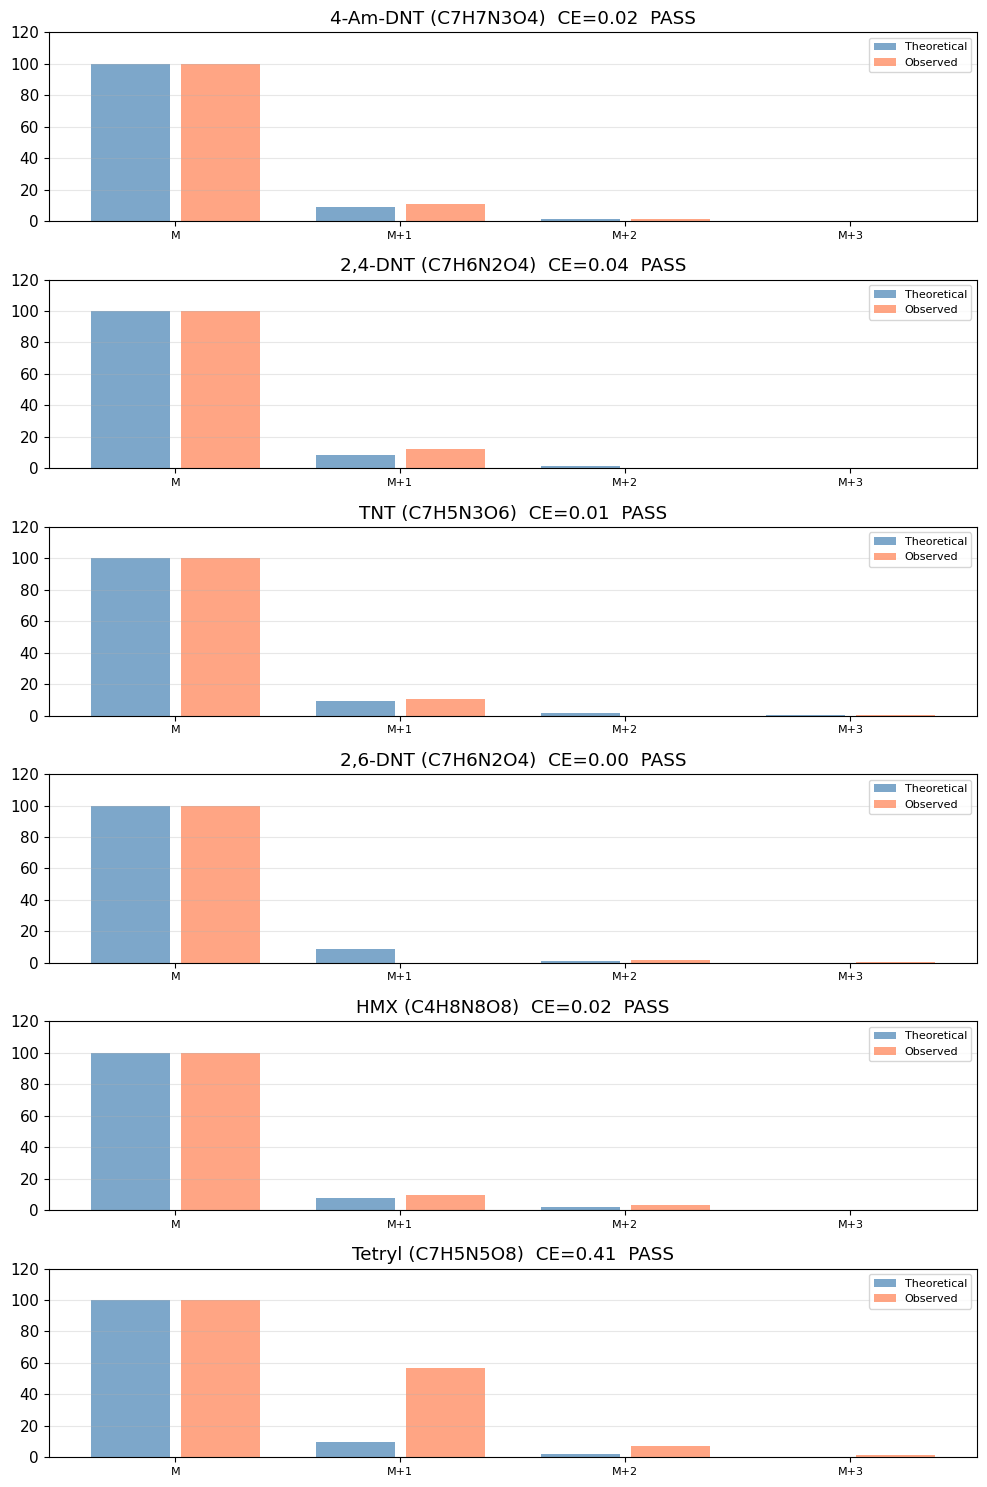

In [ ]:
# 검증 ②: Isotope Pattern
print('=== 검증 2: Isotope Pattern ===')

def isotope_cluster_error(formula, obs_mono_mz, mz_data, int_data, n_peaks=4, tol_ppm=20):
    """이론 vs 실측 Isotope Pattern 비교 → Cluster Error"""
    # 이론
    ef = oms.EmpiricalFormula(formula)
    iso = ef.getIsotopeDistribution(oms.CoarseIsotopePatternGenerator(n_peaks))
    theo = [(p.getMZ(), p.getIntensity()) for p in iso.getContainer()]
    theo_max = max(t[1] for t in theo)
    theo_rel = [t[1] / theo_max * 100 for t in theo]
    
    # 실측 클러스터 추출
    spacing = 1.00335
    obs_rel = []
    obs_found = []
    for k in range(n_peaks):
        search_mz = obs_mono_mz + k * spacing
        found_mz, found_int, _ = find_peak(mz_data, int_data, search_mz, tol_ppm)
        obs_found.append(found_int if found_int else 0)
    
    obs_max = max(obs_found) if max(obs_found) > 0 else 1
    obs_rel = [v / obs_max * 100 for v in obs_found]
    
    # Cluster Error (base peak 제외)
    base_idx = obs_rel.index(100.0) if 100.0 in obs_rel else 0
    sum_sq = 0.0
    norm_sq = 100.0 ** 2
    for j in range(min(len(theo_rel), len(obs_rel))):
        if j == base_idx or obs_found[j] == 0:
            continue
        diff = abs(theo_rel[j] - obs_rel[j])
        sum_sq += diff ** 2
        norm_sq += obs_rel[j] ** 2
    
    ce = math.sqrt(sum_sq / norm_sq) if norm_sq > 0 else 999
    return ce, theo_rel, obs_rel

print(f'{"Name":12s} {"Formula":12s} {"Cluster Err":>11s} {"PASS?":>6s}')
print('-' * 45)

fig, axes = plt.subplots(len(reaction_scheme['compounds']), 1,
                         figsize=(10, 2.5 * len(reaction_scheme['compounds'])))

for ax, comp in zip(axes, reaction_scheme['compounds']):
    if not comp['detected']:
        comp['isotope_pass'] = False
        comp['cluster_error'] = 999
        print(f"{comp['name']:12s} {comp['formula']:12s} {'---':>11s} {'FAIL':>6s}")
        ax.set_visible(False)
        continue
    
    ce, theo_rel, obs_rel = isotope_cluster_error(
        comp['formula'], comp['mz'], mz_data, int_data
    )
    comp['cluster_error'] = ce
    comp['isotope_pass'] = ce < 15
    mark = 'PASS' if ce < 15 else 'FAIL'
    print(f"{comp['name']:12s} {comp['formula']:12s} {ce:11.2f} {mark:>6s}")
    
    # 시각화
    x = np.arange(len(theo_rel))
    ax.bar(x - 0.2, theo_rel, 0.35, color='steelblue', alpha=0.7, label='Theoretical')
    ax.bar(x + 0.2, obs_rel[:len(x)], 0.35, color='coral', alpha=0.7, label='Observed')
    ax.set_xticks(x)
    ax.set_xticklabels([f'M+{j}' if j else 'M' for j in range(len(x))], fontsize=8)
    ax.set_title(f"{comp['name']} ({comp['formula']})  CE={ce:.2f}  {'PASS' if ce < 15 else 'FAIL'}")
    ax.set_ylim(0, 120)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 검증 3: Multi-Adduct 동시 검출

- 같은 분자량의 화합물이 여러 adduct로 동시에 검출되는지 확인
- **2개 이상** adduct 검출 시 동정 신뢰도 높음

In [ ]:
# 검증 ③: Multi-Adduct 동시 검출
print('=== 검증 3: Multi-Adduct ===')

ALL_NEG_ADDUCTS = [
    ('[M-H]-',       -PROTON),
    ('[M+FA-H]-',    44.99820),
    ('[M+CH3COO]-',  59.01385),
    ('[M+Cl]-',      34.96885),
]

print(f'{"Name":12s} {"MW":>10s}', end='')
for aname, _ in ALL_NEG_ADDUCTS:
    print(f' {aname:>14s}', end='')
print(f' {"Count":>6s} {"PASS?":>6s}')
print('-' * 90)

for comp in reaction_scheme['compounds']:
    mw = comp['mw']
    n_found = 0
    line = f"{comp['name']:12s} {mw:10.4f}"
    
    for aname, shift in ALL_NEG_ADDUCTS:
        pred_mz = mw + shift
        found_mz, found_int, _ = find_peak(mz_data, int_data, pred_mz)
        if found_mz is not None:
            n_found += 1
            line += f' {found_int:14.0f}'
        else:
            line += f' {"---":>14s}'
    
    comp['adducts_found'] = n_found
    comp['adduct_pass'] = n_found >= 2
    mark = 'PASS' if n_found >= 2 else 'FAIL'
    line += f' {n_found:>6d} {mark:>6s}'
    print(line)

---
## 4. 최종 판정

3중 검증 결과를 종합하여 각 화합물의 동정 신뢰도를 판정합니다.

| 통과 수 | 판정 | 의미 |
|---------|------|------|
| 3/3 | **CONFIRMED** | 확실히 존재 |
| 2/3 | **PROBABLE** | 높은 확률로 존재 |
| 1/3 | **TENTATIVE** | 가능성 있음 |
| 0/3 | **NOT DETECTED** | 검출 안 됨 |

In [ ]:
# 최종 판정표
print(f"\n{'='*90}")
print(f"{'Name':12s} {'Role':10s} {'MassAcc':>8s} {'Isotope':>8s} {'Adduct':>8s} {'Score':>6s} {'Verdict':>12s}")
print(f"{'='*90}")

for comp in reaction_scheme['compounds']:
    checks = [
        comp.get('mass_pass', False),
        comp.get('isotope_pass', False),
        comp.get('adduct_pass', False),
    ]
    score = sum(checks)
    
    if score == 3:
        verdict = 'CONFIRMED'
    elif score == 2:
        verdict = 'PROBABLE'
    elif score == 1:
        verdict = 'TENTATIVE'
    else:
        verdict = 'NOT DETECTED'
    
    comp['verdict'] = verdict
    comp['score'] = score
    
    m = 'PASS' if checks[0] else 'FAIL'
    i = 'PASS' if checks[1] else 'FAIL'
    a = 'PASS' if checks[2] else 'FAIL'
    print(f"{comp['name']:12s} {comp['role']:10s} {m:>8s} {i:>8s} {a:>8s} {score:>5d}/3 {verdict:>12s}")

### 판정 결과 히트맵

- 3중 검증 결과를 히트맵으로 시각화
- 초록 = 통과, 빨강 = 미통과

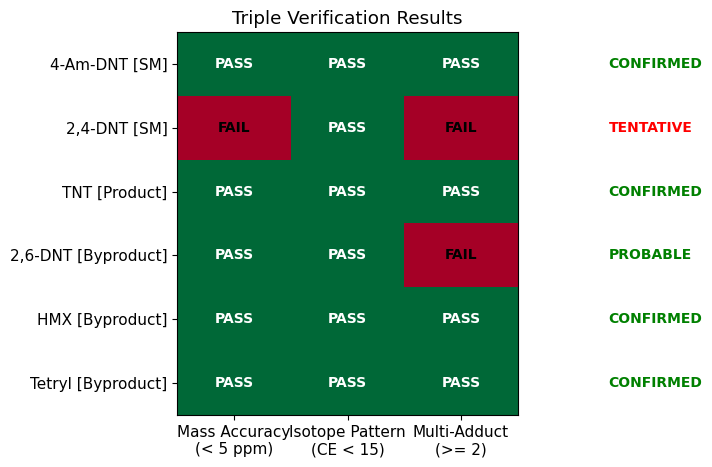

In [ ]:
# 판정 시각화: 히트맵
names = [c['name'] for c in reaction_scheme['compounds']]
checks_matrix = []
for c in reaction_scheme['compounds']:
    checks_matrix.append([
        1 if c.get('mass_pass') else 0,
        1 if c.get('isotope_pass') else 0,
        1 if c.get('adduct_pass') else 0,
    ])

fig, ax = plt.subplots(figsize=(8, max(3, len(names) * 0.8)))
im = ax.imshow(checks_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Mass Accuracy\n(< 5 ppm)', 'Isotope Pattern\n(CE < 15)', 'Multi-Adduct\n(>= 2)'])
ax.set_yticks(range(len(names)))
ax.set_yticklabels([f"{c['name']} [{c['role']}]" for c in reaction_scheme['compounds']])

# 텍스트
for j in range(len(names)):
    for k in range(3):
        text = 'PASS' if checks_matrix[j][k] else 'FAIL'
        color = 'white' if checks_matrix[j][k] else 'black'
        ax.text(k, j, text, ha='center', va='center', fontsize=10, color=color, fontweight='bold')

# 판정 라벨
for j, c in enumerate(reaction_scheme['compounds']):
    ax.text(3.3, j, c['verdict'], ha='left', va='center', fontsize=10,
           fontweight='bold', color='green' if c['score'] >= 2 else 'red')

ax.set_title('Triple Verification Results')
plt.tight_layout()
plt.show()

---
## 5. Relative Ion Abundance 산출

검증 통과 화합물의 면적비를 계산합니다.

- **SM 잔존율**: 4-Am-DNT + 2,4-DNT가 전체에서 차지하는 비율
- **Product 비율**: TNT가 전체에서 차지하는 비율 = 전환율 참고 지표
- **Byproduct 비율**: 2,6-DNT + HMX + Tetryl = 부반응 정도

### Relative Ion Abundance 산출

- 3중 검증을 통과한 화합물만 대상으로 면적비 계산
- 검증 미통과 화합물은 정량 대상에서 제외

In [ ]:
# Relative Ion Abundance 산출 (검증 통과 화합물만)
df = pd.DataFrame([{
    'name': c['name'],
    'role': c['role'],
    'formula': c['formula'],
    'mz': c['mz'],
    'area': c['area'],
    'peak_height': c['peak_height'],
    'verdict': c['verdict'],
    'score': c['score'],
} for c in reaction_scheme['compounds']])

# 전체 면적 (검증된 것만)
df_verified = df[df['score'] >= 2].copy()  # PROBABLE 이상
total_area = df_verified['area'].sum()

if total_area > 0:
    df_verified['area_%'] = df_verified['area'] / total_area * 100
else:
    df_verified['area_%'] = 0

product_area = df_verified[df_verified['role'] == 'Product']['area'].sum()
sm_area = df_verified[df_verified['role'] == 'SM']['area'].sum()

yield_pct = product_area / total_area * 100 if total_area > 0 else 0
conversion_pct = (1 - sm_area / total_area) * 100 if total_area > 0 else 0

# 미설명 피크 비율 (검증 안 된 면적 / 전체)
total_all = df['area'].sum()
unexplained = df[df['score'] < 2]['area'].sum()
unexplained_pct = unexplained / total_all * 100 if total_all > 0 else 0

print('=== 검증된 화합물 면적 ===')
print(df_verified[['name', 'role', 'area', 'area_%', 'verdict']].to_string(index=False))
print(f'\n  Product Area%: {yield_pct:.1f}%')
print(f'  SM Area Fraction:          {conversion_pct:.1f}%')
print(f'  미설명 피크 비율:       {unexplained_pct:.1f}%')

# 신뢰도 판정
if unexplained_pct < 5:
    reliability = '높음 (미설명 < 5%)'
elif unexplained_pct < 20:
    reliability = '보통 (미설명 < 20%)'
else:
    reliability = '낮음 (미설명 >= 20%)'
print(f'  Relative Ion Abundance 신뢰도:            {reliability}')

### 최종 결과 시각화

- 면적 비교 bar chart, 조성비 pie chart, 검증 점수 분포

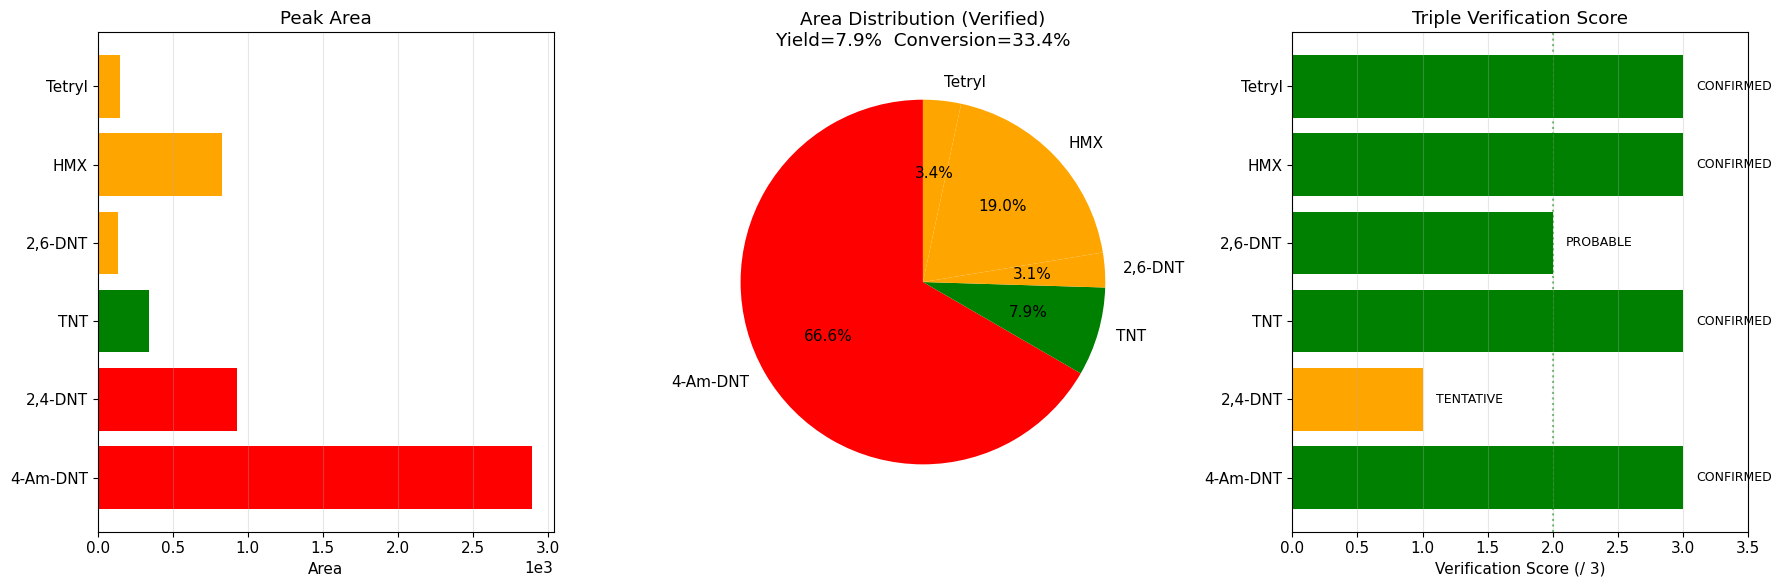

In [ ]:
# 최종 결과 시각화
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# 1. 면적 비교
colors = [colors_role[c['role']] for c in reaction_scheme['compounds']]
names_all = [c['name'] for c in reaction_scheme['compounds']]
areas_all = [c['area'] for c in reaction_scheme['compounds']]

ax1.barh(names_all, areas_all, color=colors)
ax1.set_xlabel('Area')
ax1.set_title('Peak Area')
ax1.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
ax1.grid(alpha=0.3, axis='x')

# 2. 면적 파이차트 (검증된 것만)
if len(df_verified) > 0:
    pie_colors = [colors_role[r] for r in df_verified['role']]
    ax2.pie(df_verified['area_%'], labels=df_verified['name'],
           colors=pie_colors, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Area Distribution (Verified)\nYield={yield_pct:.1f}%  Conversion={conversion_pct:.1f}%')

# 3. 검증 점수
scores = [c['score'] for c in reaction_scheme['compounds']]
bar_colors = ['green' if s >= 2 else 'orange' if s == 1 else 'red' for s in scores]
ax3.barh(names_all, scores, color=bar_colors)
ax3.set_xlabel('Verification Score (/ 3)')
ax3.set_title('Triple Verification Score')
ax3.set_xlim(0, 3.5)
ax3.axvline(2, color='green', linestyle=':', alpha=0.5, label='PROBABLE threshold')
for j, (name, score) in enumerate(zip(names_all, scores)):
    verdict = reaction_scheme['compounds'][j]['verdict']
    ax3.text(score + 0.1, j, verdict, va='center', fontsize=9)
ax3.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## 6. 커스텀 반응 스킴

아래 셀의 `reaction_scheme`을 수정하여 **자신의 반응**에 적용할 수 있습니다.

In [ ]:
# ========================================
# 사용자 정의 반응 스킴 (여기를 수정하세요)
# ========================================
# 분자식과 adduct만 입력하면 m/z 자동 계산 → XIC → 검증 → Relative Ion Abundance

my_scheme = {
    'name': 'Custom Reaction',
    'compounds': [
        {'name': 'RDX',    'role': 'SM',        'formula': 'C3H6N6O6',  'adduct': '[M+CH3COO]-', 'mz': None},
        {'name': 'HMX',    'role': 'Product',   'formula': 'C4H8N8O8',  'adduct': '[M+CH3COO]-', 'mz': None},
        {'name': 'Tetryl', 'role': 'Byproduct', 'formula': 'C7H5N5O8',  'adduct': '[M-H]-',      'mz': None},
    ]
}

# m/z 자동 계산
for comp in my_scheme['compounds']:
    ef = oms.EmpiricalFormula(comp['formula'])
    mw = ef.getMonoWeight()
    shift = ADDUCT_SHIFTS.get(comp['adduct'], -PROTON)
    comp['mw'] = mw
    comp['mz'] = round(mw + shift, 4)

# XIC + 적분
for comp in my_scheme['compounds']:
    rt, intensity = extract_xic(exp, comp['mz'])
    area, peak_rt, peak_h = summation_integrate(rt, intensity)
    comp['rt'] = rt
    comp['xic'] = intensity
    comp['area'] = area
    comp['peak_height'] = peak_h
    comp['detected'] = peak_h > 0

# Relative Ion Abundance
total = sum(c['area'] for c in my_scheme['compounds'])
prod = sum(c['area'] for c in my_scheme['compounds'] if c['role'] == 'Product')
sm = sum(c['area'] for c in my_scheme['compounds'] if c['role'] == 'SM')

print(f"=== {my_scheme['name']} ===")
for c in my_scheme['compounds']:
    pct = c['area'] / total * 100 if total > 0 else 0
    print(f"  [{c['role']:10s}] {c['name']:10s} Area={c['area']:.2e}  ({pct:.1f}%)")
print(f"\n  Yield: {prod/total*100:.1f}%  |  Conversion: {(1-sm/total)*100:.1f}%")

---
## Summary

| 단계 | 내용 |
|------|------|
| 스킴 정의 | SM + Product + Byproduct 전부 포함 |
| m/z 예측 | Adduct + ISF fragment m/z 자동 계산 |
| XIC + 적분 | 각 m/z에 대해 XIC 추출, drop별 적분 |
| 3중 검증 | Mass Accuracy + Isotope + Multi-Adduct |
| 조성비 | 검증 통과 화합물의 면적비 |

**부산물은 별도 단계가 아니라 스킴에 포함되어 동일 파이프라인을 거칩니다.**

---

⬅️ **Prev:** [Reaction Prediction](12%20Reaction%20Prediction.ipynb)